# Eigenvalue shape examples

Illustrates the shapes of the ordered eigenvalues of an affine matrix pencil, including the monotone case obtained with a positive-semidefinite direction matrix.

In [1]:
import numpy as np
import scipy.linalg as sla
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["figure.dpi"] = 140

In [2]:
def random_symmetric(rng, dim):
    lower = np.tril(rng.random((dim, dim)))
    return lower + np.tril(lower, -1).T


def univariate_spectral(A, B, k, xs):
    """Computes the vector y[i] = λₖ(A + xs[i] B)."""
    # Support negative eigenvalue indices, e.g. k=-1 is the largest eigenvalue.
    k = k % A.shape[0]
    mats = A + B * xs[..., np.newaxis, np.newaxis]
    return sla.eigvalsh(mats, subset_by_index=(k, k)).squeeze(-1)

In [3]:
def spec_neuron_gallery(A, B):
    """Plot every λₖ(A + xB) on its own axis."""
    n_eigenvalues = A.shape[-1]
    n_cols = min(3, n_eigenvalues)
    n_rows = int(np.ceil(n_eigenvalues / n_cols))
    fig, axs = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5.9 * n_cols / 3, 1.5 * n_rows),
        squeeze=False,
        layout="constrained",
    )
    plot_xs = np.linspace(-3, 3, 1000)
    axes = axs.ravel()
    for k, ax in enumerate(axes[:n_eigenvalues]):
        ax.plot(plot_xs, univariate_spectral(A, B, k, plot_xs))
        ax.set_title(rf"$\lambda_{{{1 + k}}}(A + xB)$")
    for ax in axes[n_eigenvalues:]:
        ax.set_visible(False)
    return fig

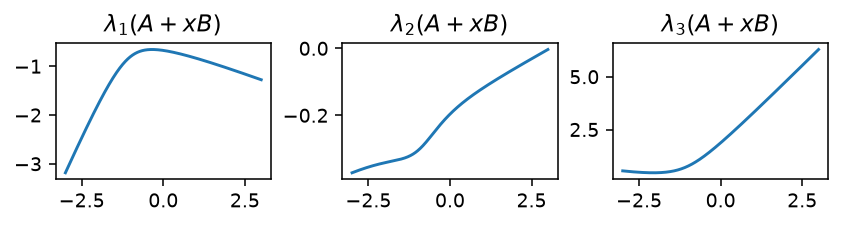

In [4]:
rng = np.random.default_rng(42)
A = random_symmetric(rng, 3)
B = random_symmetric(rng, 3)
spec_neuron_gallery(A, B);

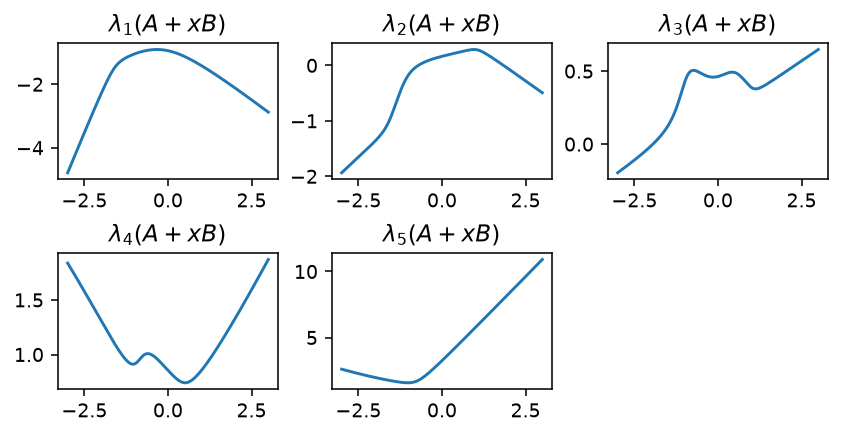

In [5]:
rng = np.random.default_rng(42)
A = random_symmetric(rng, 5)
B = random_symmetric(rng, 5)
spec_neuron_gallery(A, B);

In [6]:
def spec_neuron_multiplot(A, B):
    """Plot every λₖ(A + xB) on one axis."""
    fig, ax = plt.subplots(figsize=(3.8, 3), layout="constrained")
    plot_xs = np.linspace(-3, 3, 1000)

    color_indices = np.linspace(0, 1, 2 + A.shape[-1])[1:-1]
    colors = mpl.colormaps["berlin"](color_indices)
    widths = np.linspace(1.5, 2.5, A.shape[-1])

    for k in range(A.shape[-1]):
        ax.plot(
            plot_xs,
            univariate_spectral(A, B, k, plot_xs),
            label=rf"$\lambda_{{{1 + k}}}(A + xB)$",
            linewidth=widths[k],
            color=colors[k],
        )
    ax.grid()
    ax.legend()
    return fig

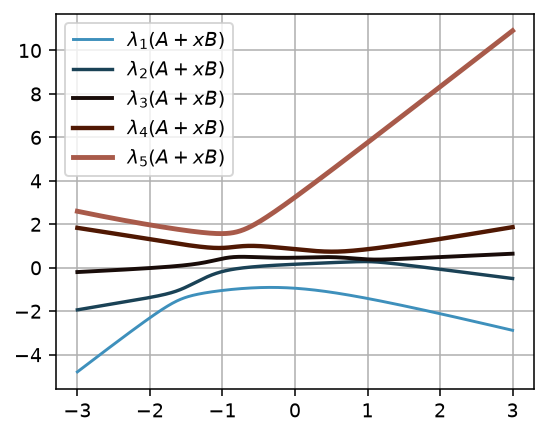

In [7]:
spec_neuron_multiplot(A, B);

In [8]:
def make_psd(B):
    eigvals, eigvecs = sla.eigh(B)
    eigvals_pos = np.maximum(0, eigvals)
    return eigvecs @ np.diag(eigvals_pos) @ eigvecs.T

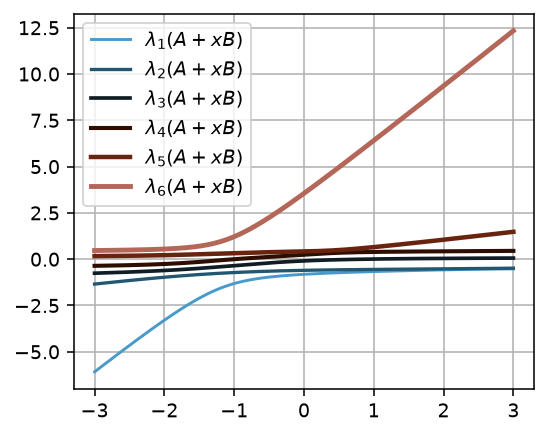

In [9]:
rng = np.random.default_rng(42)
A = random_symmetric(rng, 6)
B = random_symmetric(rng, 6)
spec_neuron_multiplot(A, make_psd(B));

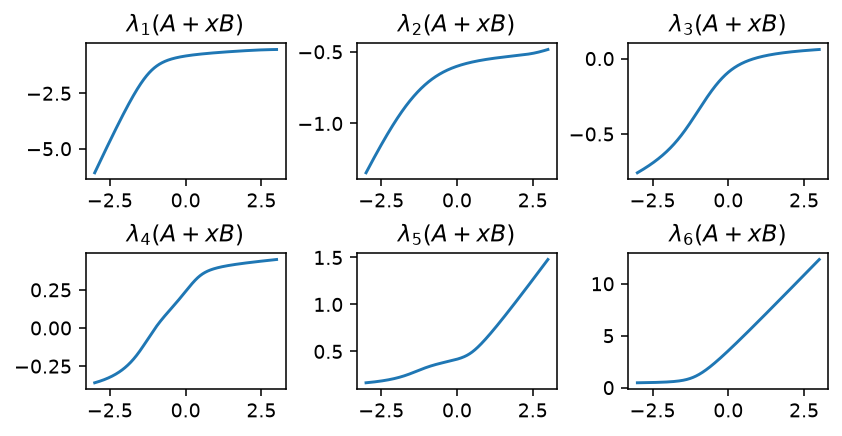

In [10]:
spec_neuron_gallery(A, make_psd(B));